In [ ]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest

In [ ]:
SEED = 1500
np.random.seed(SEED)

## Визуализируйте ряд, пометив аномальные точки

In [ ]:
data = pd.read_csv('skab_valve_1.csv', sep=';', parse_dates=['datetime'])
data['anomaly'] = data['anomaly'].astype(int)
data.head(10)

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
0,2020-03-09 12:34:37,0.028030,0.040400,1.182850,0.054711,69.9219,24.9122,229.918,32.9875,0,0.0
1,2020-03-09 12:34:38,0.026952,0.038880,1.452680,-0.273216,69.9147,24.9038,219.566,32.0129,0,0.0
2,2020-03-09 12:34:39,0.027958,0.040660,1.023000,0.054711,69.8861,24.9055,237.717,32.9875,0,0.0
3,2020-03-09 12:34:40,0.027277,0.040736,1.227510,-0.273216,69.8397,24.9110,227.621,32.0000,0,0.0
4,2020-03-09 12:34:41,0.027210,0.039489,1.215260,-0.273216,69.9136,24.9110,221.634,32.0129,0,0.0
5,2020-03-09 12:34:42,0.027988,0.041497,1.145650,0.382638,69.9164,24.9225,237.289,32.9875,0,0.0
6,2020-03-09 12:34:43,0.027520,0.041009,0.765551,0.382638,69.8105,24.9225,218.470,32.0129,0,0.0
7,2020-03-09 12:34:44,0.027578,0.040065,1.095710,0.382638,69.8265,24.9233,230.436,32.9875,0,0.0
8,2020-03-09 12:34:45,0.028223,0.041788,1.249210,0.382638,69.8300,24.9155,233.562,32.0129,0,0.0
9,2020-03-09 12:34:46,0.027627,0.041255,1.161170,0.054711,69.9031,24.9228,229.929,32.9875,0,0.0


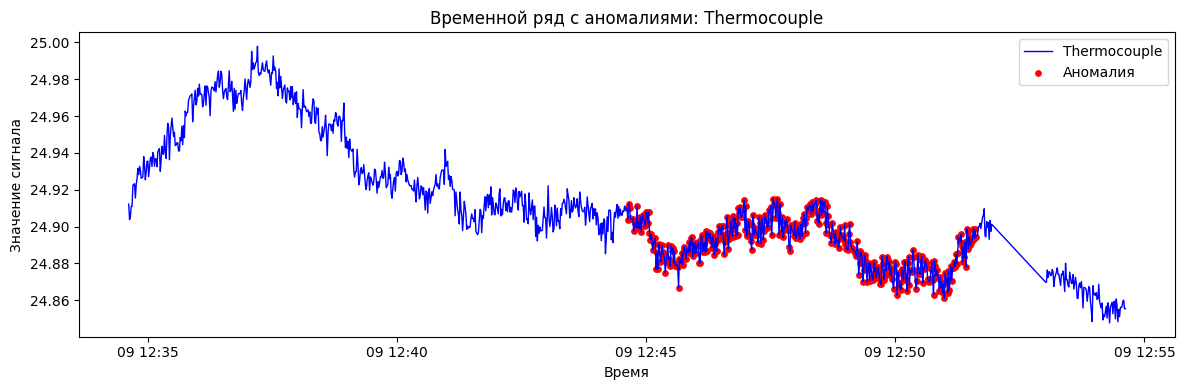

In [ ]:
signal = 'Thermocouple'
datetime = 'datetime'
anomaly = 'anomaly'

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    data[datetime],
    data[signal],
    color='b',
    lw=1,
    label=signal
)

if anomaly in data.columns:
    anom_mask = data[anomaly] == 1

    ax.scatter(
        data.loc[anom_mask, datetime],
        data.loc[anom_mask, signal],
        color='r',
        s=15,
        label='Аномалия'
    )

ax.set_title(f'Временной ряд с аномалиями: {signal}')
ax.set_xlabel('Время')
ax.set_ylabel('Значение сигнала')
ax.legend()

plt.tight_layout()
plt.show()


# Поиск аномалий

In [ ]:
def calculate_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    res = {
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'f1': (2*tp) / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0
    }
    return cm, res

def pred_pl(ts, y_true, y_pred, value, title):
    ts = np.asarray(ts)
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    value = np.asarray(value)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ts, value, color='blue', lw=1.0, alpha=0.9, label='signal', zorder=1)

    ax.scatter(ts[y_true == 1],
               value[y_true == 1],
               s=10, c='red', alpha=0.3,
               label='True anomaly', zorder=2)

    ax.scatter(ts[y_pred == 1],
               value[y_pred == 1],
               s=10, c='yellow', alpha=0.3,
               label='Pred anomaly', zorder=3)

    ax.set_title(title)
    ax.set_xlabel('Время')
    ax.set_ylabel('Значение')
    ax.legend(ncol=3, fontsize=9, frameon=True)
    plt.tight_layout()
    plt.show()

# Статистические эвристики

### Реализуйте фильтрацию аномалий на основе расчитанных статистик [Q1 - (1.5 * IQR), Q3 + (1.5 * IQR)], [Q1 - (3 * IQR), Q3 + (3 * IQR)]

In [ ]:
def metric_eval(series, k=1.5):
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return low, high

In [ ]:
y_true = data['anomaly'].values

low15, high15 = metric_eval(data[signal].values, k=1.5)
pred_iqr15 = ((data[signal] < low15) | (data[signal] > high15)).astype(int)

low3, high3 = metric_eval(data[signal].values, k=3.0)
pred_iqr3 = ((data[signal] < low3) | (data[signal] > high3)).astype(int)

### Визуализируйте результаты работы модели, оцените качество визуально

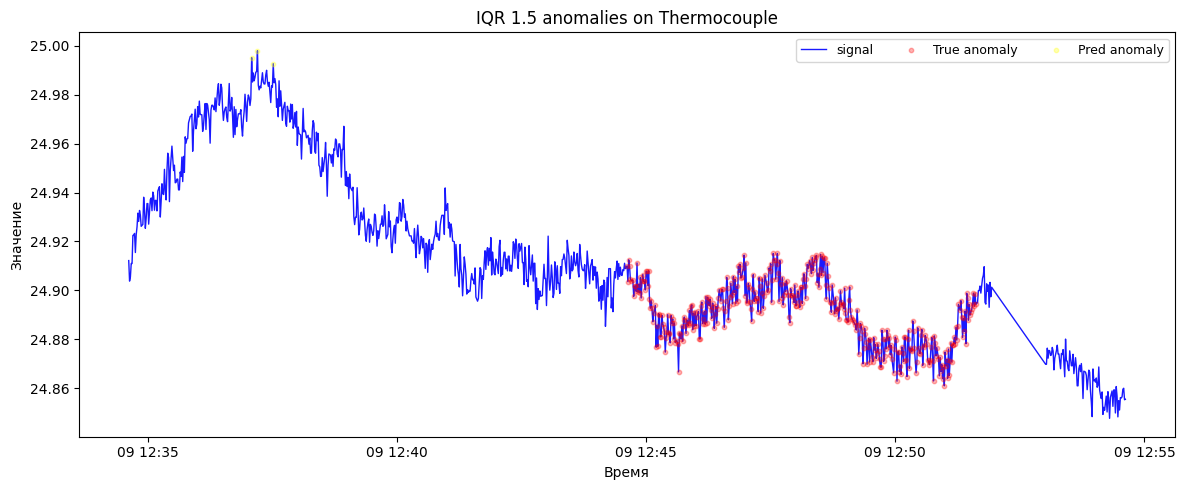

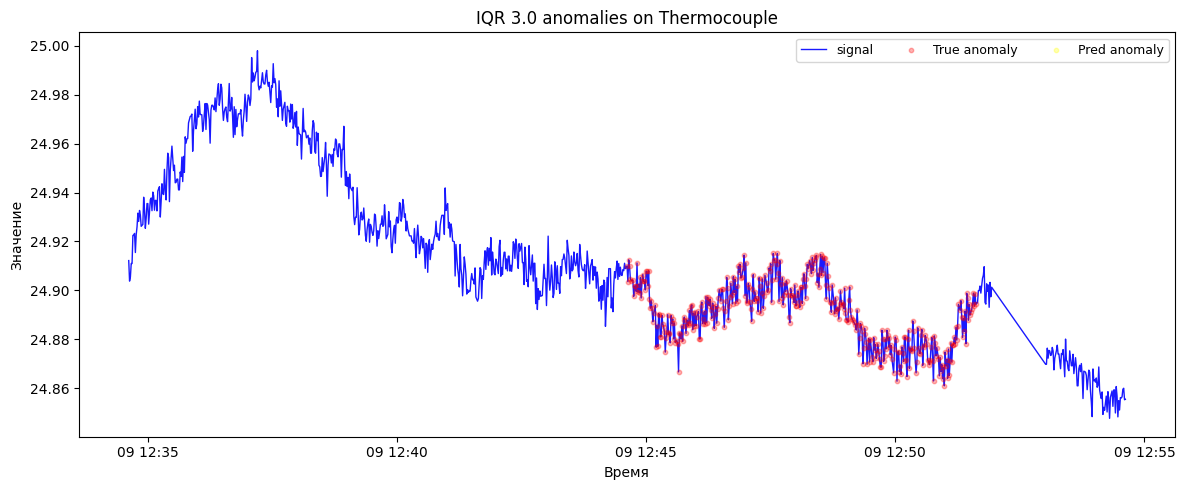

In [ ]:
pred_pl(data['datetime'].values, y_true, pred_iqr15, data[signal].values,
                 f'IQR 1.5 anomalies on {signal}')
pred_pl(data['datetime'].values, y_true, pred_iqr3, data[signal].values,
                 f'IQR 3.0 anomalies on {signal}')

На графиках видно, что аномалия - это плавное смещение уровня без резких скачков. Метод IQR почти не замечает такие изменения: при k = 1.5 появляются лишь редкие ложные точки, а при k = 3.0 - почти ничего. Это показывает, что IQR плохо подходит для поиска плавных долгих отклонений.

### Оцените качество, построив confusion matrix для предсказаний и исходных данных

In [ ]:
cm_iqr15, res_iqr15 = calculate_metrics(y_true, pred_iqr15)
cm_iqr3, res_iqr3 = calculate_metrics(y_true, pred_iqr3)

print('IQR 1.5:', res_iqr15)
print(cm_iqr15)
print('IQR 3.0:', res_iqr3)
print(cm_iqr3)

IQR 1.5: {'tn': np.int64(686), 'fp': np.int64(3), 'fn': np.int64(405), 'tp': np.int64(0), 'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}
[[686   3]
 [405   0]]
IQR 3.0: {'tn': np.int64(689), 'fp': np.int64(0), 'fn': np.int64(405), 'tp': np.int64(0), 'precision': 0.0, 'recall': np.float64(0.0), 'f1': np.float64(0.0)}
[[689   0]
 [405   0]]


Confusion matrix показывает, что метод IQR не подходит для обнаружения плавных трендовых изменений: при любом значении k модель не фиксирует настоящие аномалии (TP = 0), а только иногда даёт ложные сигналы. Precision, recall и F1 равны нулю - это значит, что модель не смогла правильно обнаружить ни одной аномалии.

# Кластеризация

### Используйте Feature-Engineering для создания признаков

In [ ]:
base_cols = [
    'Accelerometer1RMS','Accelerometer2RMS','Current','Pressure',
    'Temperature','Thermocouple','Voltage','Volume Flow RateRMS'
]

fe = data.copy()

for col in base_cols:
    fe[f'{col}_lag1'] = fe[col].shift(1)
    fe[f'{col}_lag2'] = fe[col].shift(2)

window = 10
for col in base_cols:
    fe[f'{col}_roll_mean'] = fe[col].rolling(window).mean()
    fe[f'{col}_roll_std'] = fe[col].rolling(window).std()

fe['minute'] = fe['datetime'].dt.minute
fe['second'] = fe['datetime'].dt.second

fe_ml = fe.dropna().reset_index(drop=True)

X_cols = [c for c in fe_ml.columns if c not in ['datetime','anomaly','changepoint']]
X = fe_ml[X_cols].values
y_true_ml = fe_ml['anomaly'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Реализуйте фильтрацию аномалий на основе модели кластеризации

In [ ]:
kmeans = KMeans(n_clusters=1, random_state=SEED, n_init='auto')
kmeans.fit(X_scaled)
dists = np.linalg.norm(X_scaled - kmeans.cluster_centers_[0], axis=1)

threshold = np.quantile(dists, 0.99)
pred_kmeans = (dists > threshold).astype(int)

In [ ]:
dbscan = DBSCAN(eps=6.8, min_samples=60)
labels = dbscan.fit_predict(X_scaled)
pred_dbscan = (labels == -1).astype(int)

В данном блоке реализовано выявление аномалий с помощью моделей кластеризации из библиотеки scikit-learn. Использованы два алгоритма: KMeans и DBSCAN.
Модель KMeans обучается с одним кластером, и аномалиями считаются точки, которые находятся дальше определённого порога от центра кластера.
Модель DBSCAN определяет аномалии как точки, не принадлежащие ни одному кластеру (они получают метку -1). Параметры eps и min_samples были подобраны эмпирически.

### Визуализируйте результаты работы модели, оцените качество визуально

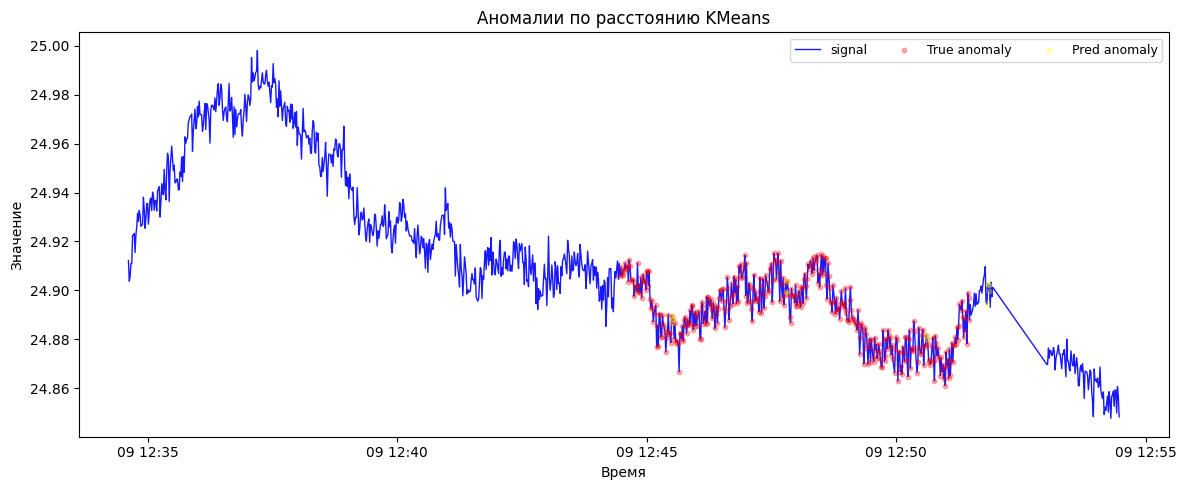

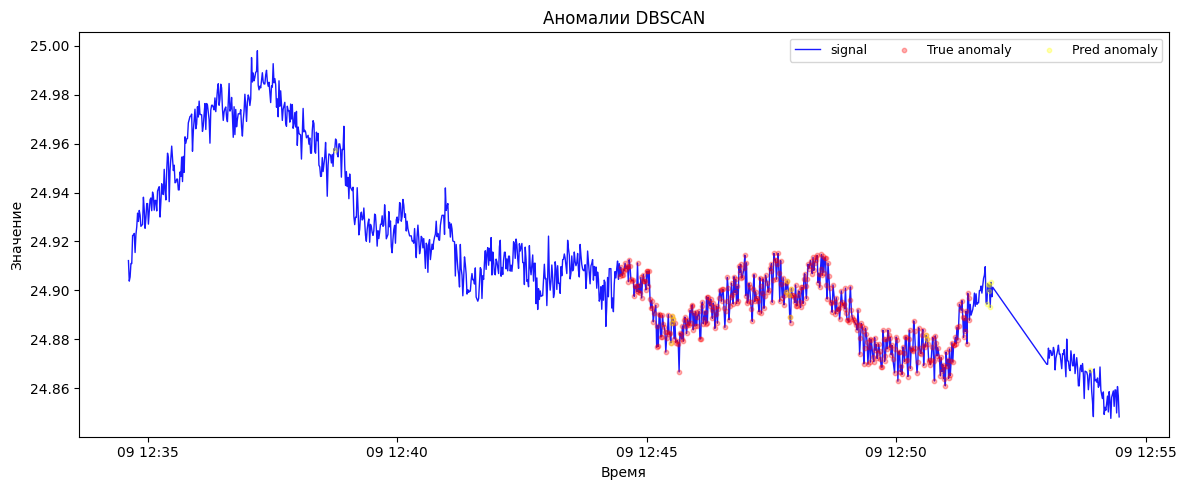

In [ ]:
idx_map = fe_ml.index
pred_pl(data.loc[idx_map, 'datetime'].values,
                 y_true_ml,
                 pred_kmeans,
                 data.loc[idx_map, signal].values,
                 'Аномалии по расстоянию KMeans')

pred_pl(data.loc[idx_map, 'datetime'].values,
                 y_true_ml,
                 pred_dbscan,
                 data.loc[idx_map, signal].values,
                 'Аномалии DBSCAN')

На представленных графиках видно, что предсказанные аномалии в целом совпадают с размеченным интервалом, однако распределены внутри него крайне неравномерно. DBSCAN визуально выделяет несколько больше точек чем Kmeans, но также не покрывает большую часть аномального сегмента. Это показывает, что оба метода лишь частично распознают область аномалии, но не способны полностью охватить её и корректно описать по всей длительности интервала.

### Оцените качество, построив confusion matrix для предсказаний и исходных данных

In [ ]:
cm_kmean, res_kmean = calculate_metrics(y_true_ml, pred_kmeans)
print('KMeans результат:', res_kmean)
print(cm_kmean)
cm_dbscan, res_dbscan = calculate_metrics(y_true_ml, pred_dbscan)
print('DBSCAN results:', res_dbscan)
print(cm_dbscan)


KMeans результат: {'tn': np.int64(676), 'fp': np.int64(4), 'fn': np.int64(398), 'tp': np.int64(7), 'precision': np.float64(0.6363636363636364), 'recall': np.float64(0.01728395061728395), 'f1': np.float64(0.03365384615384615)}
[[676   4]
 [398   7]]
DBSCAN results: {'tn': np.int64(672), 'fp': np.int64(8), 'fn': np.int64(394), 'tp': np.int64(11), 'precision': np.float64(0.5789473684210527), 'recall': np.float64(0.027160493827160494), 'f1': np.float64(0.05188679245283019)}
[[672   8]
 [394  11]]


Для модели KMeans показатель precision около 0.64 при крайне низких значениях recall и F1-score. Это говорит о том, что алгоритм хорошо различает нормальные объекты и почти не ошибается при их классификации, однако практически не выявляет аномалии. Такой результат подтверждает визуальные наблюдения: модель редко попадает в размеченные аномальные области.
Алгоритм DBSCAN демонстрирует немного более высокие значения полноты и F1-score по сравнению с KMeans, что указывает на небольшое улучшение способности к обнаружению выбросов. При этом количество ложных срабатываний увеличивается незначительно. Это согласуется с визуальным анализом - DBSCAN отмечает больше точек внутри аномального сегмента, сохраняя при этом устойчивость на нормальных участках сигнала.

# Isolation Forest

### Реализуйте фильтрацию аномалий на основе модели Isolation Forest

In [ ]:
iso = IsolationForest(
    n_estimators=1000,
    max_samples='auto',
    contamination=0.01,
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_scaled)
scores = iso.decision_function(X_scaled)
pred_iso = (iso.predict(X_scaled) == -1).astype(int)

### Визуализируйте результаты работы модели, оцените качество визуально

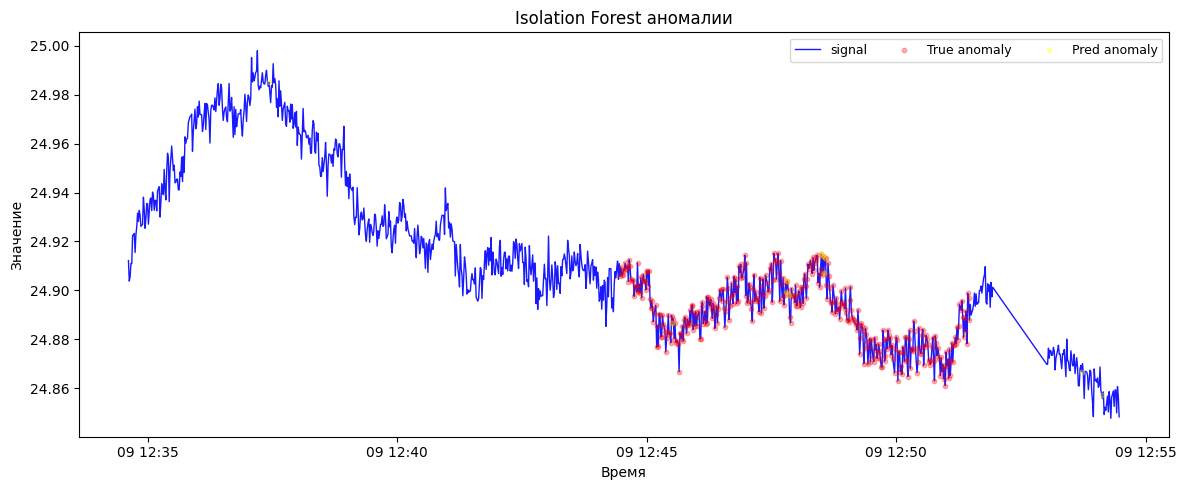

In [ ]:
pred_pl(data.loc[idx_map, 'datetime'].values,
                 y_true_ml,
                 pred_iso,
                 data.loc[idx_map, signal].values,
                 'Isolation Forest аномалии')

Мы видим, что модель работает достаточно хорошо, за сегментов практически нет срабатываний, а внутри сегмента видим сработки - что значит мы имеем низкий уровень ложных срабатываний. Но при этом осталась проблема внутри сегмента - значительная часть аномалий не выявлена.

### Оцените качество, построив confusion matrix для предсказаний и исходных данных

In [ ]:
cm_iso, res_iso = calculate_metrics(y_true_ml, pred_iso)
print('Isolation Forest results:', res_iso)
print(cm_iso)

Isolation Forest results: {'tn': np.int64(677), 'fp': np.int64(3), 'fn': np.int64(397), 'tp': np.int64(8), 'precision': np.float64(0.7272727272727273), 'recall': np.float64(0.019753086419753086), 'f1': np.float64(0.038461538461538464)}
[[677   3]
 [397   8]]


У модели высокая точность precision≈0.8,
recall≈0.022 и низкий f1.
Наша модель мало ошибается, но при этом не занимает нужно область, именно это мы и видели при визуальном анализе

# Соберите агрегированные результаты по всем экспериментам в отдельный датафрейм и сравните между собой, сделайте выводы

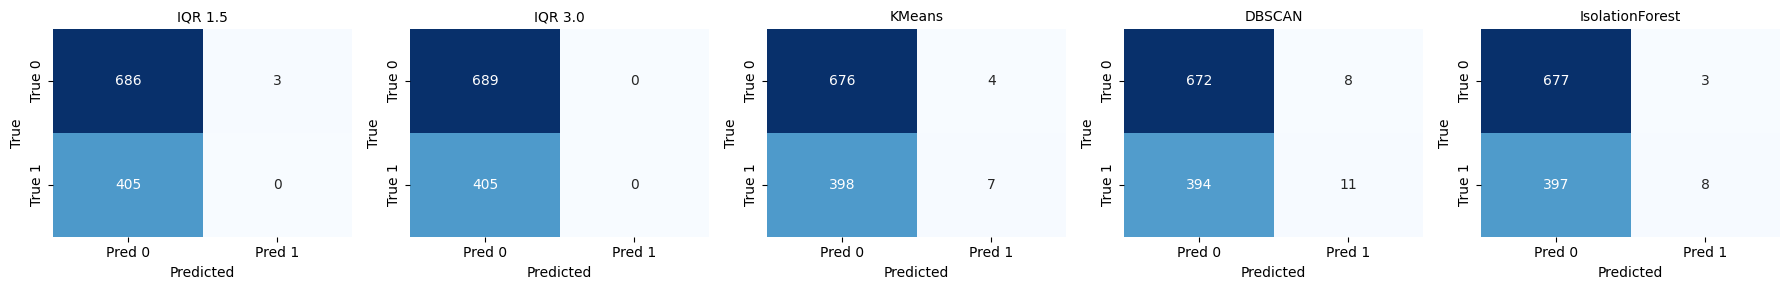

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))

models = [
    (cm_iqr15, 'IQR 1.5'),
    (cm_iqr3, 'IQR 3.0'),
    (cm_kmean, 'KMeans'),
    (cm_dbscan, 'DBSCAN'),
    (cm_iso, 'IsolationForest')
]

for ax, (cm, title) in zip(axes, models):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                ax=ax, cbar=False)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()


In [ ]:
results = pd.DataFrame([
    {'model': 'IQR_1.5', **res_iqr15},
    {'model': 'IQR_3.0', **res_iqr3},
    {'model': 'KMeansDist', **res_kmean},
    {'model': 'DBSCAN', **res_dbscan},
    {'model': 'IsolationForest', **res_iso},
])

cols = ['model','tn','fp','fn','tp','precision','recall','f1']
results = results[cols].sort_values('f1', ascending=False).reset_index(drop=True)
results

,model,tn,fp,fn,tp,precision,recall,f1
0,DBSCAN,672,8,394,11,0.578947,0.027160,0.051887
1,IsolationForest,677,3,397,8,0.727273,0.019753,0.038462
2,KMeansDist,676,4,398,7,0.636364,0.017284,0.033654
3,IQR_1.5,686,3,405,0,0.000000,0.000000,0.000000
4,IQR_3.0,689,0,405,0,0.000000,0.000000,0.000000


Лучший результат показал алгоритм DBSCAN, получивший наибольшее значение F1-меры (≈0.052) за счёт более сбалансированного соотношения точности и полноты.
IsolationForest продемонстрировал схожие показатели, отличаясь более высокой точностью, но меньшей чувствительностью к аномалиям.
Метод KMeansDist показал слабую полноту, выявляя лишь отдельные отклонения.
Обе версии IQR-детектора не обнаружили аномалий, что делает их непригодными для текущего типа данных.